In [4]:
# ----------------------------------------
# STUDENT PERFORMANCE PREDICTION SYSTEM ---> By Sidharth
# ----------------------------------------

# 1. Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [5]:
# 2. Loading Dataset
print("Loading Dataset...\n")

data = pd.read_csv("student-mat.csv", sep=';')

print("First 5 Rows of Dataset:")
print(data.head())

Loading Dataset...

First 5 Rows of Dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [16]:
# 3. Dataset Information
print("\nDataset Information:\n")
print(data.info())



Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   famsize     395 non-null    int64
 5   Pstatus     395 non-null    int64
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    int64
 9   Fjob        395 non-null    int64
 10  reason      395 non-null    int64
 11  guardian    395 non-null    int64
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    int64
 16  famsup      395 non-null    int64
 17  paid        395 non-null    int64
 18  activities  395 non-null    int64
 19  nursery     395 non-null    int64
 20  higher   

In [17]:
# 4. Checking Missing Values
print("\nMissing Values:\n")
print(data.isnull().sum())




Missing Values:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [18]:
# 5. Encoding Categorical Variables
print("\nEncoding Categorical Columns...")

label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

print("\nEncoded Dataset Preview:")
print(data.head())



Encoding Categorical Columns...

Encoded Dataset Preview:
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         6   5   6   6  
1       5         3      3     1     1       3         4   5   5   6  
2       4         3      2     2     3       3        10   7   8  10  
3       3         2      2     1     1       5         2  15  14  15  
4       4         3      2     1     2       5         4   6  10  10  

[5 rows x 33 columns]



Generating Correlation Heatmap...


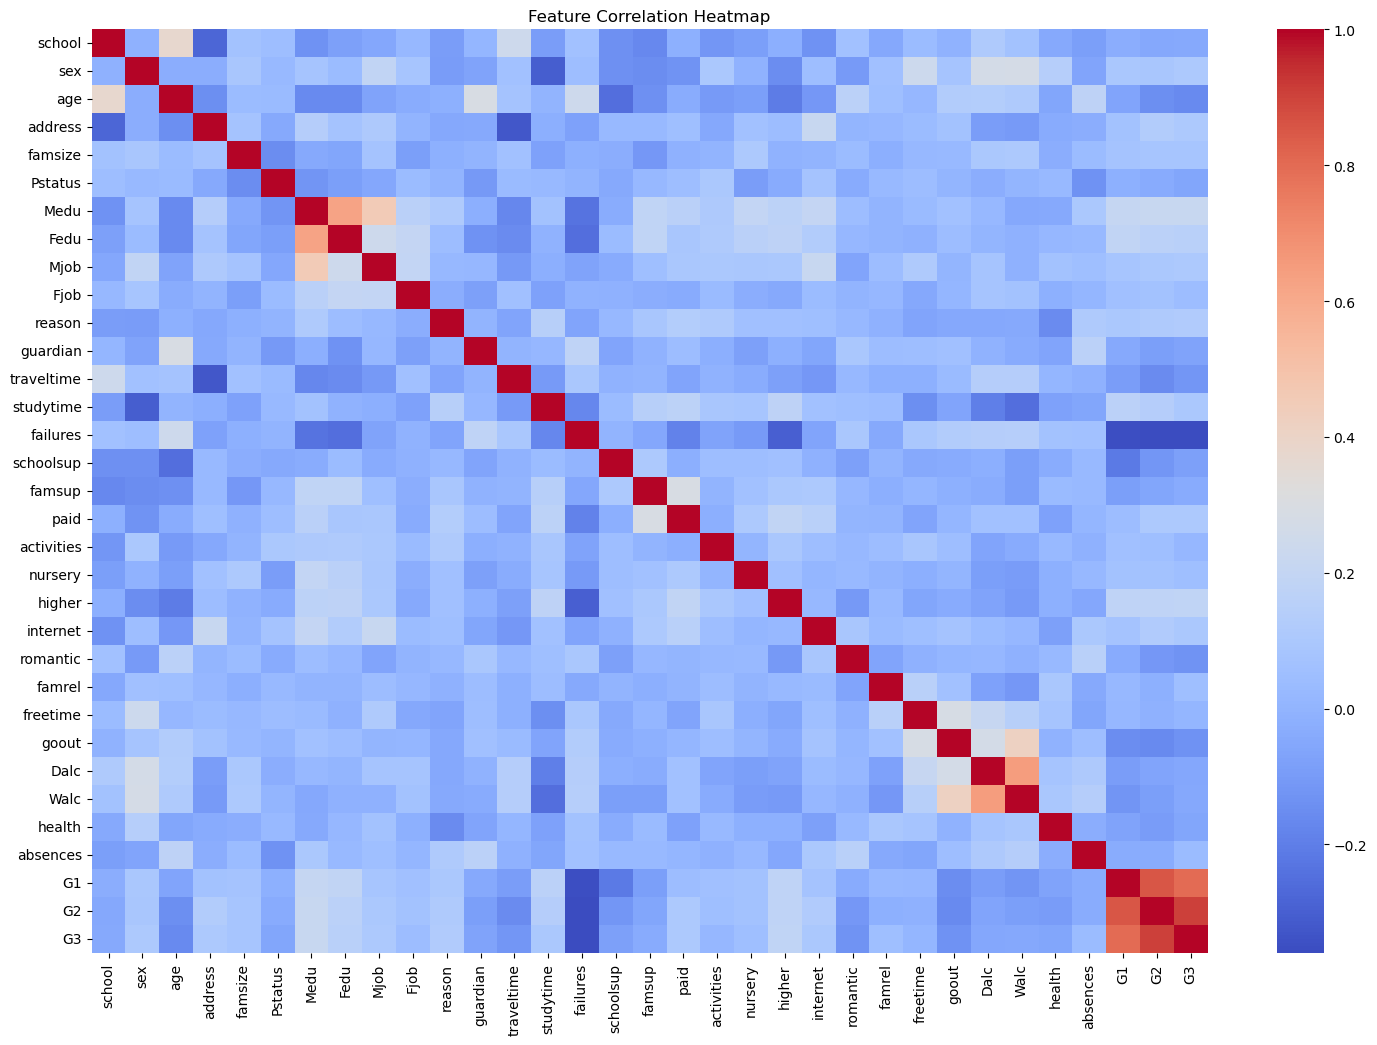

In [9]:
# 6. Exploratory Data Analysis
print("\nGenerating Correlation Heatmap...")

plt.figure(figsize=(18,12))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()



In [18]:
# 7. Feature Selection
X = data.drop("G3", axis=1)   # Input Features
y = data["G3"]                # Target Variable




In [11]:
# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)





Training Samples: (316, 32)
Testing Samples: (79, 32)


In [20]:
# 9. Model Training
print("\nTraining Linear Regression Model...")

model = LinearRegression()
model.fit(X_train, y_train)





Training Linear Regression Model...


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# 10. Prediction
predictions = model.predict(X_test)

print("\nSample Predictions:\n")
print(predictions[:10])






Sample Predictions:

[ 6.28152491 11.32691676  3.03252133  8.03726136  8.55577788 12.36703933
 18.68481592  7.54069216  6.98823227 12.36020452]


In [14]:
# 11. Model Evaluation

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation Results")
print("------------------------")
print("RMSE:", rmse)
print("R² Score:", r2)





Model Evaluation Results
------------------------
RMSE: 2.2432998258963828
R² Score: 0.75457778550435


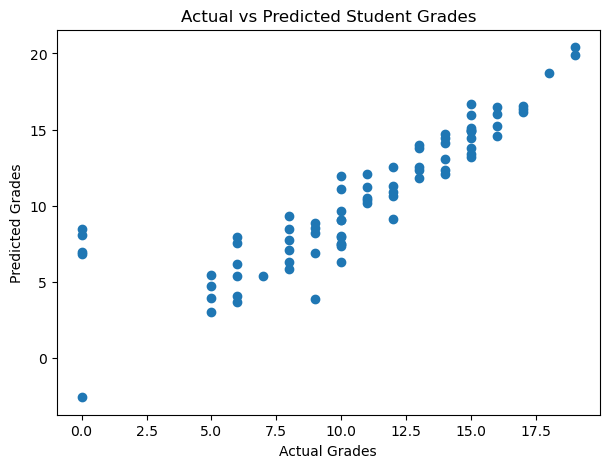


Project Execution Completed Successfully!


In [15]:
# 12. Visualization: Actual vs Predicted

plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Student Grades")
plt.show()


print("\nProject Execution Completed Successfully!")